###

In [545]:
import numpy as np

class DirectPaste:
    def __init__(self, dest_img, src_img, cropped_source, cropped_mask, centre_y, centre_x):

        self.dest_img = dest_img
        self.src_img = src_img
        self.cropped_source = cropped_source
        self.cropped_mask = cropped_mask
        self.centre_x = centre_x
        self.centre_y = centre_y

    def apply(self):

        result = self.dest_img.copy()

        patch_height, patch_width = self.src_img.shape[:2]
        dest_height, dest_width = self.dest_img.shape[:2]

        top_left_x = self.centre_x - patch_width // 2
        top_left_y = self.centre_y - patch_height // 2

        valid_top_left_x = max(top_left_x, 0)
        valid_top_left_y = max(top_left_y, 0)

        valid_bottom_right_x = min(top_left_x + patch_width, dest_width)
        valid_bottom_right_y = min(top_left_y + patch_height, dest_height)

        result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x] = np.where(
            self.cropped_mask[..., None] == 1,
            self.cropped_source,
            result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x]
        )
        
        return result

In [560]:
import numpy as np
import cv2

class AlphaBlending:
    def __init__(self, dest_img, cropped_source, cropped_mask, centre_x, centre_y, feather_radius=15):

        self.dest_img = dest_img
        self.cropped_source = cropped_source
        self.cropped_mask = cropped_mask
        self.feather_radius = feather_radius
        self.centre_x = centre_x
        self.centre_y = centre_y

    def apply(self):

        result = self.dest_img.copy()

        patch_height, patch_width = self.cropped_source.shape[:2]
        dest_height, dest_width = self.dest_img.shape[:2]

        top_left_x = self.centre_x - patch_width // 2
        top_left_y = self.centre_y - patch_height // 2

        valid_top_left_x = max(top_left_x, 0)
        valid_top_left_y = max(top_left_y, 0)
        valid_bottom_right_x = min(top_left_x + patch_width, dest_width)
        valid_bottom_right_y = min(top_left_y + patch_height, dest_height)

        cropped_source = self.cropped_source[:valid_bottom_right_y - valid_top_left_y, :valid_bottom_right_x - valid_top_left_x]
        cropped_mask = self.cropped_mask[:valid_bottom_right_y - valid_top_left_y, :valid_bottom_right_x - valid_top_left_x]

        feathered_mask = cv2.GaussianBlur(cropped_mask.astype(np.float32), (self.feather_radius, self.feather_radius), 0)
        feathered_mask = feathered_mask[..., None]  

        for c in range(3):  
            result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x, c] = (
                cropped_source[:, :, c] * feathered_mask[:, :, 0] +
                result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x, c] * (1 - feathered_mask[:, :, 0])
            )
        
        return result


In [567]:
import cv2
import numpy as np
from PIL import Image
import scipy as sp

class PoissonBlending:
    def __init__(self, placement_image, dest_img, placement_mask):
        self.placement_image = placement_image
        self.dest_img = dest_img
        self.placement_mask = placement_mask
    
    def read_image(self, path_to_image: str, mask_image: bool, scale: bool=False):
    
        img = Image.open(path_to_image)

        if mask_image:
            img = img.convert("L") # greyscale
            binary_mask = np.array(img) > 127
            return binary_mask.astype(np.uint8)

        img = np.array(img.convert('RGB'))
        if scale:
            return img.astype('double') / 255.0

        return img

    def apply_clahe_mask(self, image, mask):

        image_uint8 = (image * 255).clip(0, 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)

        lab = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2LAB)

        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

        l_clahe_full = clahe.apply(l)

        l_clahe = l.copy()
        l_clahe[mask > 0] = l_clahe_full[mask > 0]

        lab_clahe = cv2.merge((l_clahe, a, b))

        result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

        return result

    def get_neighbours(self, i: int, j: int, max_i: int, max_j: int):
        return [(i + di, j) for di in (-1, 1) if 0 <= i + di <= max_i] + \
            [(i, j + dj) for dj in (-1, 1) if 0 <= j + dj <= max_j]
            
    def populate_normal(self, A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W):

        counter = 0
        num_mask_pixels = len(y_coords)

        for index in range(num_mask_pixels):
            y, x = y_coords[index], x_coords[index]

            for ny, nx in self.get_neighbours(y, x, H-1, W-1):
                A[counter, pixel_idx_map[y][x]] = 1
                
                b[counter] = src_image_test[y][x] - src_image_test[ny][nx]

                if pixel_idx_map[ny][nx] != -1:
                    A[counter, pixel_idx_map[ny][nx]] = -1
                else:
                    b[counter] += dest_image_test[ny][nx]

                counter += 1
        
        return A, b

    def populate_mixed(self, A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W):

        counter = 0
        num_mask_pixels = len(y_coords)

        for index in range(num_mask_pixels):
            y, x = y_coords[index], x_coords[index]

            for ny, nx in self.get_neighbours(y, x, H-1, W-1):
                d1 = src_image_test[y][x] - src_image_test[ny][nx]
                d2 = dest_image_test[y][x] - dest_image_test[ny][nx]

                strongest = d1 if abs(d1) > abs(d2) else d2

                A[counter, pixel_idx_map[y][x]] = 1
                
                b[counter] = strongest

                if pixel_idx_map[ny][nx] != -1:
                    A[counter, pixel_idx_map[ny][nx]] = -1
                else:
                    b[counter] += dest_image_test[ny][nx]

                counter += 1
        
        return A, b

    def compute_poisson_blend_channel(self, src_image_test, dest_image_test, mask, mode):

        H, W = src_image_test.shape

        num_mask_pixels = mask.sum().astype(int)
        pixel_idx_map = np.full(mask.shape, -1, dtype=int)
        y_coords, x_coords = np.where(mask == 1)
        pixel_idx_map[mask > 0] = np.arange(num_mask_pixels)

        A = sp.sparse.lil_matrix((4 * num_mask_pixels, num_mask_pixels))
        b = np.zeros(4 * num_mask_pixels)

        if mode=='normal':

            A, b = self.populate_normal(A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W)

        if mode=='mixed':
            A, b = self.populate_mixed(A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W)


        A = sp.sparse.csr_matrix(A)
        v = sp.sparse.linalg.lsqr(A, b)[0]

        copy_dest = dest_image_test.copy()

        for index in range(num_mask_pixels):
            y, x = y_coords[index], x_coords[index]
            copy_dest[y][x] = v[pixel_idx_map[y][x]]

        
        return np.clip(copy_dest, 0, 1)
    
    def apply(self):
        pcomp_result_initial = np.dstack([
            self.compute_poisson_blend_channel(self.placement_image[:, :, c]/255., self.dest_img[:, :, c]/255., self.placement_mask, mode='normal')
            for c in range(3)
        ])
        
        pcomp_result = self.apply_clahe_mask(pcomp_result_initial, self.placement_mask)

        return pcomp_result, pcomp_result_initial

In [580]:
import numpy as np
import cv2
from placement import PlaceFinder


class RealSyn:
    def __init__(self, source, target, mask, method='poisson', resize_shape=None):
        self.source = source
        self.target = target
        self.mask = mask
        self.resize_shape = resize_shape
        self.method = method

    def run(self):

        placer = PlaceFinder(dest_img=self.target, src_img=self.source, src_mask=self.mask, verbose=False)
        resized_image, cropped_fit_source, cropped_fit_mask, placement_mask, placement_image, centre_x, centre_y = placer.run()

        if self.method == 'direct':
            composer = DirectPaste(dest_img=self.target, src_img=resized_image, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y)
            result = composer.apply()
            #result = direct_paste(dest_img=target, src_img=resized_image, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y)

        elif self.method == 'alpha':
            composer = AlphaBlending(dest_img=self.target, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y, feather_radius=15)
            result = composer.apply()
            #result = alpha_blending(dest_img=target, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y, feather_radius=15)

        elif self.method == 'poisson':
            composer = PoissonBlending(placement_image=placement_image, dest_img=self.target, placement_mask=placement_mask)
            result, _ = composer.apply()

        if self.resize_shape:
            result = cv2.resize(result, (self.resize_shape[1], self.resize_shape[0]))
            placement_mask = cv2.resize(placement_mask, (self.resize_shape[1], self.resize_shape[0]))

        return result, np.expand_dims(placement_mask, axis=2)

In [624]:
import os
import numpy as np
from torch.utils.data import Dataset
import torch
import cv2
import glob
import random
import imgaug.augmenters as iaa # traditional argumentations
from perlin import rand_perlin_2d_np
from realsyn import compute_poisson_blend_channel, apply_clahe_mask, direct_paste, alpha_blending 
from placement import PlaceFinder

def perlin(anomaly_img_augmented, image, resize_shape):

        perlin_scale = 6
        min_perlin_scale = 0
        
        rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])
        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()

        perlin_noise = rand_perlin_2d_np((resize_shape[0], resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        return augmented_image, perlin_thr

def cutpaste(source, destination):

    augmented_image = destination.copy()
    source = source.astype(np.float32)/255.
    height, width, _ = destination.shape
    mask = np.zeros((height, width), dtype=np.uint8)
    num_patches = random.randint(1, 5)

    for _ in range(num_patches):
        use_scar = random.choice([True, False])

        if use_scar:
            patch_width = random.randint(10, 40)
            patch_height = random.randint(50, 200)

            source_top_left_x = random.randint(0, source.shape[1] - patch_width)
            source_top_left_y = random.randint(0, source.shape[0] - patch_height)
            patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

            angle = random.uniform(0, 360)
            center = (patch_width // 2, patch_height // 2)
            rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
            patch = cv2.warpAffine(patch, rotation_matrix, (patch_width, patch_height))
        else:
            patch_area_ratio = random.uniform(0.02, 0.15)
            aspect_ratio = random.uniform(0.3, 3.3)
            patch_width = int(np.sqrt(patch_area_ratio * width * height * aspect_ratio))
            patch_height = int(np.sqrt(patch_area_ratio * width * height / aspect_ratio))

            patch_width = min(patch_width, width)
            patch_height = min(patch_height, height)

            source_top_left_x = random.randint(0, source.shape[1] - patch_width)
            source_top_left_y = random.randint(0, source.shape[0] - patch_height)
            patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

            patch = cv2.flip(patch, 1) if random.random() > 0.5 else patch

        patch_height, patch_width = patch.shape[:2]

        paste_x = random.randint(0, width - patch_width)
        paste_y = random.randint(0, height - patch_height)

        if paste_y + patch_height > augmented_image.shape[0]:
            patch_height = augmented_image.shape[0] - paste_y
        if paste_x + patch_width > augmented_image.shape[1]:
            patch_width = augmented_image.shape[1] - paste_x

        patch = patch[:patch_height, :patch_width]

        augmented_image[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = patch

        mask[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = 1

    return augmented_image, np.expand_dims(mask, axis=2)

def realsyn(source, target, mask, resize_shape, method='poisson'):

    placer = PlaceFinder(dest_img=target, src_img=source, src_mask=mask, verbose=False)
    resized_image, cropped_fit_source, cropped_fit_mask, placement_mask, placement_image, centre_x, centre_y = placer.run()

    composer = RealSyn(source=source, target=target, mask=mask, method=method, resize_shape=self.resise_shape)
    result = composer.apply()

    if method == 'direct':
        composer = DirectPaste(dest_img=target, src_img=resized_image, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y)
        result = composer.apply()
        #result = direct_paste(dest_img=target, src_img=resized_image, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y)

    elif method == 'alpha':
        composer = AlphaBlending(dest_img=target, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y, feather_radius=15)
        result = composer.apply()
        #result = alpha_blending(dest_img=target, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y, feather_radius=15)

    elif method == 'poisson':
        composer = PoissonBlending(placement_image=placement_image, dest_img=target, placement_mask=placement_mask)
        result, _ = composer.apply()
        #pcomp_result_initial = np.dstack([
        #        compute_poisson_blend_channel(placement_image[:, :, c]/255., target[:, :, c]/255., placement_mask, mode='normal')
        #        for c in range(3)
        #    ])
        #result = apply_clahe_mask(pcomp_result_initial, placement_mask)

    result = cv2.resize(result, (resize_shape[1], resize_shape[0]))
    placement_mask = cv2.resize(placement_mask, (resize_shape[1], resize_shape[0]))

    return result, np.expand_dims(placement_mask, axis=2)

class FieldTrainDataset(Dataset):

    def __init__(self, image_dir, resize_shape=(256, 256*2), method='perlin', anomaly_source_dir=None):

        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape
        self.method = method

        if (self.anomaly_source_dir is None) or (self.method == 'cutpaste'):
            self.anomaly_source_dir = image_dir

        self.image_paths = sorted(glob.glob(f"{self.image_dir}/*/*.png") + glob.glob(f"{self.image_dir}/*/*.jpg") + glob.glob(f"{self.image_dir}/*/*.jpeg"))
        print(self.image_paths[0])
        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        self.anomaly_source_paths = sorted(glob.glob(f"{self.anomaly_source_dir}/*/*.png") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpg") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpeg"))
        print(self.anomaly_source_paths[0])
        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        if self.method == 'realsyn':
            self.anomaly_source_paths = [path for path in self.anomaly_source_paths if path.endswith('_source.png')]

        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
           # iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        return aug

    def augment_image(self, image, anomaly_source_path, method):

        aug = self.randAugmenter()

        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)

        if method == 'perlin':
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
            anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
            anomaly_img_augmented = aug(image=anomaly_source_img)

            augmented_image, perlin_thr = perlin(anomaly_img_augmented, image, self.resize_shape)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)

                mask = perlin_thr.astype(np.float32)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

        elif method == 'cutpaste':
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
            anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
            anomaly_img_augmented = aug(image=anomaly_source_img)
            augmented_image, mask = cutpaste(anomaly_img_augmented, image)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)
                mask = mask.astype(np.float32)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

        elif method == 'realsyn':

            other_path = anomaly_source_path.replace('_source', '_mask')
            img = cv2.imread(other_path, cv2.IMREAD_GRAYSCALE)
            source_mask = (img > 127).astype(np.uint8)

            #print(f"source_mask={source_mask.shape}")

            realsyn_method = 'alpha'#'poisson' #random.choice(['alpha', 'poisson', 'direct'])

            #augmented_image, mask = realsyn(anomaly_source_img, image, source_mask, self.resize_shape, realsyn_method)
            composer = RealSyn(source=anomaly_source_img, target=image, mask=source_mask, method=realsyn_method, resize_shape=self.resize_shape)
            augmented_image, mask = composer.run()
            
            #aau = torch.rand(1).item()
            #if aau > 0.5:
            #    augmented_image = aug(image=augmented_image)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))
                image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
                return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)/255.
                mask = mask.astype(np.float32)
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

        elif method == None:
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
            anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
            augmented_image = aug(image=anomaly_source_img)

            augmented_image = augmented_image.astype(np.float32)
            mask = np.zeros(self.resize_shape, dtype=np.float32)
            mask = np.expand_dims(mask, axis=2)
            augmented_image = mask * augmented_image + (1 - mask) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)


    def transform_image(self, image_path, anomaly_source_path, method):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if method != 'realsyn':
            image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        if (torch.rand(1).item() > 0.7) and (method != 'realsyn'):
            image = self.rot(image=image)

        #image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path, method)
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        if method == 'realsyn':
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0

        #print("before")
        #print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        #print("after")
        #print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        return image, augmented_image, anomaly_mask, has_anomaly


    def __getitem__(self, idx):
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(self.image_paths[idx],
                                                                           self.anomaly_source_paths[anomaly_source_idx], self.method)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_26_18_203.png
/home/maria/Documents/datasets/coco_anomaly/cow/103257_mask.png
<class 'numpy.ndarray'> 0.95686275 0.0 (256, 512, 3)
<class 'numpy.ndarray'> 0.98039216 0.0 (256, 512, 3)
<class 'numpy.ndarray'> 1.0 0.0 (256, 512)
(256, 512, 3)


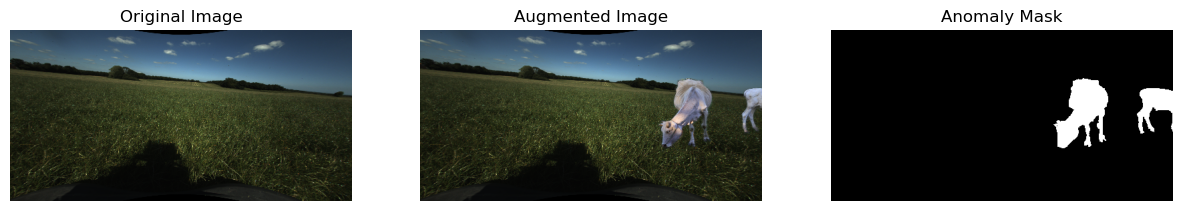

'\nbefore\n(256, 512, 3) (256, 512, 1) (1,)\nafter\n(3, 256, 512) (1, 256, 512) (1,)\n(256, 512, 3)\n'

In [628]:
import matplotlib.pyplot as plt

augmentation_tests = {
    'perlin': '/home/maria/Documents/datasets/dtd/images/',
    'cutpaste': None,
    'realsyn': '/home/maria/Documents/datasets/coco_anomaly/',
    'baseline': None  
}

test = 'realsyn'

if test == 'baseline':
    method = None
    
else:
    method = test


anomaly_source_dir = augmentation_tests[test]
image_dir = '/home/maria/Documents/dataset_splited/agco_dataset/train/'

dataset_perlin = FieldTrainDataset(image_dir=image_dir, anomaly_source_dir=anomaly_source_dir, method=method)

def visualize(dataset):
    sample = dataset[random.randint(0, len(dataset) - 1)]

    image = sample['image'].transpose(1, 2, 0) #.numpy()
    print(type(image), image.max(), image.min(), image.shape)
    augmented_image = sample['augmented_image'].transpose(1, 2, 0) #.numpy()
    print(type(augmented_image), augmented_image.max(), augmented_image.min(), augmented_image.shape)
    anomaly_mask = sample['anomaly_mask'].transpose(1, 2, 0).squeeze() #.numpy()
    print(type(anomaly_mask), anomaly_mask.max(), anomaly_mask.min(), anomaly_mask.shape)

    print(augmented_image.shape)
    
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(augmented_image)
    plt.title("Augmented Image")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(anomaly_mask, cmap='gray')
    plt.title("Anomaly Mask")
    plt.axis('off')

    plt.show()

visualize(dataset_perlin)

"""
before
(256, 512, 3) (256, 512, 1) (1,)
after
(3, 256, 512) (1, 256, 512) (1,)
(256, 512, 3)
"""

# BACKUP

In [ ]:
import os
import numpy as np
from torch.utils.data import Dataset
import torch
import cv2
import glob
import random
import imgaug.augmenters as iaa # traditional argumentations
from perlin import rand_perlin_2d_np
from realsyn import compute_poisson_blend_channel, apply_clahe_mask, direct_paste, alpha_blending 
from placement import PlaceFinder

def perlin(anomaly_img_augmented, image, resize_shape):

        perlin_scale = 6
        min_perlin_scale = 0
        
        rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])
        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()

        perlin_noise = rand_perlin_2d_np((resize_shape[0], resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        return augmented_image, perlin_thr

class FieldTrainDataset(Dataset):

    def __init__(self, image_dir, resize_shape=(256, 256*2), method='perlin', anomaly_source_dir=None):

        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape
        self.method = method

        if (self.anomaly_source_dir is None) or (self.method == 'cutpaste'):
            self.anomaly_source_dir = image_dir

        self.image_paths = sorted(glob.glob(f"{self.image_dir}/*/*.png") + glob.glob(f"{self.image_dir}/*/*.jpg") + glob.glob(f"{self.image_dir}/*/*.jpeg"))
        print(self.image_paths[0])
        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        self.anomaly_source_paths = sorted(glob.glob(f"{self.anomaly_source_dir}/*/*.png") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpg") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpeg"))
        print(self.anomaly_source_paths[0])
        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        if self.method == 'realsyn':
            self.anomaly_source_paths = [path for path in self.anomaly_source_paths if path.endswith('_source.png')]

        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
           # iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        return aug

    """
    def perlin(self, anomaly_img_augmented, image):

        perlin_scale = 6
        min_perlin_scale = 0

        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()

        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        return augmented_image, perlin_thr
    """

    def cut_paste_augment(self, source, destination):

        augmented_image = destination.copy()
        source = source.astype(np.float32)/255.
        height, width, _ = destination.shape
        mask = np.zeros((height, width), dtype=np.uint8)
        num_patches = random.randint(1, 5)

        for _ in range(num_patches):
            use_scar = random.choice([True, False])

            if use_scar:
                patch_width = random.randint(10, 40)
                patch_height = random.randint(50, 200)

                source_top_left_x = random.randint(0, source.shape[1] - patch_width)
                source_top_left_y = random.randint(0, source.shape[0] - patch_height)
                patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

                angle = random.uniform(0, 360)
                center = (patch_width // 2, patch_height // 2)
                rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
                patch = cv2.warpAffine(patch, rotation_matrix, (patch_width, patch_height))
            else:
                patch_area_ratio = random.uniform(0.02, 0.15)
                aspect_ratio = random.uniform(0.3, 3.3)
                patch_width = int(np.sqrt(patch_area_ratio * width * height * aspect_ratio))
                patch_height = int(np.sqrt(patch_area_ratio * width * height / aspect_ratio))

                patch_width = min(patch_width, width)
                patch_height = min(patch_height, height)

                source_top_left_x = random.randint(0, source.shape[1] - patch_width)
                source_top_left_y = random.randint(0, source.shape[0] - patch_height)
                patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

                patch = cv2.flip(patch, 1) if random.random() > 0.5 else patch

            patch_height, patch_width = patch.shape[:2]

            paste_x = random.randint(0, width - patch_width)
            paste_y = random.randint(0, height - patch_height)

            if paste_y + patch_height > augmented_image.shape[0]:
                patch_height = augmented_image.shape[0] - paste_y
            if paste_x + patch_width > augmented_image.shape[1]:
                patch_width = augmented_image.shape[1] - paste_x

            patch = patch[:patch_height, :patch_width]

            augmented_image[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = patch

            mask[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = 1

        return augmented_image, np.expand_dims(mask, axis=2)

    def realsyn(self, source, target, mask, method='poisson'):

        placer = PlaceFinder(dest_img=target, src_img=source, src_mask=mask, verbose=False)
        resized_image, cropped_fit_source, cropped_fit_mask, placement_mask, placement_image, centre_x, centre_y = placer.run()

        if method == 'direct':
            result = direct_paste(dest_img=target, src_img=resized_image, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y)

        elif method == 'alpha':
            result = alpha_blending(dest_img=target, cropped_source=cropped_fit_source, cropped_mask=cropped_fit_mask, centre_x=centre_x, centre_y=centre_y, feather_radius=15)

        elif method == 'poisson':
            pcomp_result_initial = np.dstack([
                    compute_poisson_blend_channel(placement_image[:, :, c]/255., target[:, :, c]/255., placement_mask, mode='normal')
                    for c in range(3)
                ])
            result = apply_clahe_mask(pcomp_result_initial, placement_mask)

        result = cv2.resize(result, (self.resize_shape[1], self.resize_shape[0]))
        placement_mask = cv2.resize(placement_mask, (self.resize_shape[1], self.resize_shape[0]))

        return result, np.expand_dims(placement_mask, axis=2)

    def augment_image(self, image, anomaly_source_path, method):

        aug = self.randAugmenter()

        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)

        if method == 'perlin':
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
            anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
            anomaly_img_augmented = aug(image=anomaly_source_img)

            augmented_image, perlin_thr = perlin(anomaly_img_augmented, image, self.resize_shape)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)

                mask = perlin_thr.astype(np.float32)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

        elif method == 'cutpaste':
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
            anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
            anomaly_img_augmented = aug(image=anomaly_source_img)
            augmented_image, mask = self.cut_paste_augment(anomaly_img_augmented, image)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)
                mask = mask.astype(np.float32)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

        elif method == 'realsyn':

            other_path = anomaly_source_path.replace('_source', '_mask')
            img = cv2.imread(other_path, cv2.IMREAD_GRAYSCALE)
            source_mask = (img > 127).astype(np.uint8)

            #print(f"source_mask={source_mask.shape}")

            method = 'direct' #random.choice(['alpha', 'poisson', 'direct'])

            augmented_image, mask = self.realsyn(anomaly_source_img, image, source_mask, method=method)
            augmented_image = aug(image=augmented_image)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))
                image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
                return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)/255.
                mask = mask.astype(np.float32)
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

        elif method == None:
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
            anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
            augmented_image = aug(image=anomaly_source_img)

            augmented_image = augmented_image.astype(np.float32)
            mask = np.zeros(self.resize_shape, dtype=np.float32)
            mask = np.expand_dims(mask, axis=2)
            augmented_image = mask * augmented_image + (1 - mask) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)


    def transform_image(self, image_path, anomaly_source_path, method):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if method != 'realsyn':
            image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        if (torch.rand(1).item() > 0.7) and (method != 'realsyn'):
            image = self.rot(image=image)

        #image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path, method)
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        if method == 'realsyn':
            image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0

        #print("before")
        #print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        #print("after")
        #print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        return image, augmented_image, anomaly_mask, has_anomaly


    def __getitem__(self, idx):
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(self.image_paths[idx],
                                                                           self.anomaly_source_paths[anomaly_source_idx], self.method)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

In [1]:
import sys
sys.path.append('/home/maria/Documents/projects/anomaly_detection_vehicles')

In [412]:
import os
import numpy as np
from torch.utils.data import Dataset
import torch
import cv2
import glob
import random
import imgaug.augmenters as iaa # traditional argumentations
from perlin import rand_perlin_2d_np 

class FieldTrainDataset(Dataset):

    def __init__(self, image_dir, resize_shape=(256, 256*2), method='perlin', anomaly_source_dir=None):

        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape
        self.method = method

        if (self.anomaly_source_dir is None) or (self.method != 'perlin'):
            self.anomaly_source_dir = image_dir

        self.image_paths = sorted(glob.glob(f"{self.image_dir}/*/*.png") + glob.glob(f"{self.image_dir}/*/*.jpg") + glob.glob(f"{self.image_dir}/*/*.jpeg")) 
        print(self.image_paths[0])
        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        self.anomaly_source_paths = sorted(glob.glob(f"{self.anomaly_source_dir}/*/*.png") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpg") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpeg")) 
        print(self.anomaly_source_paths[0])
        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        # TODO: add which trad_da where selected
        
        return aug
    
    def perlin(self, anomaly_img_augmented, image):

        perlin_scale = 6
        min_perlin_scale = 0

        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        
        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        return augmented_image, perlin_thr

    def cut_paste_augment(self, source, destination):

        augmented_image = destination.copy()
        source = source.astype(np.float32)/255.
        #plt.imshow(source)
        height, width, _ = destination.shape
        mask = np.zeros((height, width), dtype=np.uint8)  
        num_patches = random.randint(1, 5)

        for _ in range(num_patches):
            use_scar = random.choice([True, False])

            if use_scar:
                patch_width = random.randint(10, 40)
                patch_height = random.randint(50, 200)

                source_top_left_x = random.randint(0, source.shape[1] - patch_width)
                source_top_left_y = random.randint(0, source.shape[0] - patch_height)
                patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

                angle = random.uniform(0, 360)
                center = (patch_width // 2, patch_height // 2)
                rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
                patch = cv2.warpAffine(patch, rotation_matrix, (patch_width, patch_height))
            else:
                patch_area_ratio = random.uniform(0.02, 0.15)
                aspect_ratio = random.uniform(0.3, 3.3)
                patch_width = int(np.sqrt(patch_area_ratio * width * height * aspect_ratio))
                patch_height = int(np.sqrt(patch_area_ratio * width * height / aspect_ratio))

                patch_width = min(patch_width, width)
                patch_height = min(patch_height, height)

                source_top_left_x = random.randint(0, source.shape[1] - patch_width)
                source_top_left_y = random.randint(0, source.shape[0] - patch_height)
                patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

                patch = cv2.flip(patch, 1) if random.random() > 0.5 else patch

            patch_height, patch_width = patch.shape[:2]

            paste_x = random.randint(0, width - patch_width)
            paste_y = random.randint(0, height - patch_height)

            if paste_y + patch_height > augmented_image.shape[0]:
                patch_height = augmented_image.shape[0] - paste_y
            if paste_x + patch_width > augmented_image.shape[1]:
                patch_width = augmented_image.shape[1] - paste_x

            patch = patch[:patch_height, :patch_width]

            augmented_image[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = patch
            
            mask[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = 1

        return augmented_image, np.expand_dims(mask, axis=2)
    
    def augment_image(self, image, anomaly_source_path, method):
        
        aug = self.randAugmenter()

        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB) 
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)

        if method == 'perlin':
            augmented_image, perlin_thr = self.perlin(anomaly_img_augmented, image)
        
            # apply the ano_da
            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)
                mask = perlin_thr.astype(np.float32)
                #print("mask")
                #print(mask.shape)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)
        
        elif method == 'cutpaste':
            augmented_image, mask = self.cut_paste_augment(anomaly_img_augmented, image)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)
                mask = mask.astype(np.float32)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)
            
        elif method == 'realsyn':
            pass

        elif method == None:
            pass


    def transform_image(self, image_path, anomaly_source_path, method):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path, method)
        
        #print("before")
        #print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)
        
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        #print("after")
        #print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)
        
        return image, augmented_image, anomaly_mask, has_anomaly
        

    def __getitem__(self, idx):
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()
        print(anomaly_source_idx, self.anomaly_source_paths[anomaly_source_idx])
        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(self.image_paths[idx],
                                                                           self.anomaly_source_paths[anomaly_source_idx], self.method)
        
        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_26_18_203.png
/home/maria/Documents/datasets/dtd/images/banded/banded_0002.jpg
<class 'numpy.ndarray'> 235 0
<class 'numpy.ndarray'> 0.92156863 0.0
<class 'numpy.ndarray'> 0.0 0.0
(256, 512, 3)


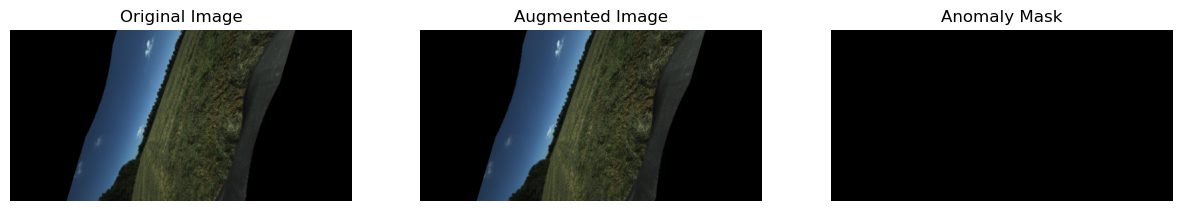

'\nbefore\n(256, 512, 3) (256, 512, 1) (1,)\nafter\n(3, 256, 512) (1, 256, 512) (1,)\n(256, 512, 3)\n'

In [410]:
import matplotlib.pyplot as plt

image_dir = '/home/maria/Documents/dataset_splited/agco_dataset/train/'
anomaly_source_dir = '/home/maria/Documents/datasets/dtd/images/'

dataset_perlin = FieldTrainDataset(image_dir=image_dir, anomaly_source_dir=anomaly_source_dir, method='perlin')

def visualize_sample(dataset):
    sample = dataset[random.randint(0, len(dataset) - 1)]

    image = sample['image'].transpose(1, 2, 0)
    print(type(image), image.max(), image.min())
    augmented_image = sample['augmented_image'].transpose(1, 2, 0)
    print(type(augmented_image), augmented_image.max(), augmented_image.min())
    anomaly_mask = sample['anomaly_mask'].transpose(1, 2, 0).squeeze()
    print(type(anomaly_mask), anomaly_mask.max(), anomaly_mask.min())

    print(augmented_image.shape)
    
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(augmented_image)
    plt.title("Augmented Image")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(anomaly_mask, cmap='gray')
    plt.title("Anomaly Mask")
    plt.axis('off')

    plt.show()

visualize_sample(dataset_perlin)

"""
before
(256, 512, 3) (256, 512, 1) (1,)
after
(3, 256, 512) (1, 256, 512) (1,)
(256, 512, 3)
"""

#### OLDER ONE

In [303]:
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

class CustomTrainDataset(Dataset):

    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):
        """
        Args:
            image_dir (string): Directory with all the training images.
            anomaly_source_dir (string): Directory with images to introduce anomalies.
            resize_shape (tuple): Desired image size (height, width).
        """
        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        # Collect all image paths (supporting .png, .jpg, .jpeg)
        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        return aug

    def augment_image(self, image, anomaly_source_path):
        aug = self.randAugmenter()
        perlin_scale = 6
        min_perlin_scale = 0

        # Load and resize the anomaly source image
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
        #anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)

        # Generate Perlin noise
        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        no_anomaly = torch.rand(1).item()
        if no_anomaly > 0.5:
            return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
        else:
            augmented_image = augmented_image.astype(np.float32)
            mask = perlin_thr.astype(np.float32)
            augmented_image = mask * augmented_image + (1 - mask) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

    def transform_image(self, image_path, anomaly_source_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #filename = "/home/maria/Documents/projects/anomaly_detection_vehicles/TEST_FIELD_1_/visualisations/ORIGINAL.png"
        #plt.imsave(filename, image)
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        # Apply random rotation
        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image and generate the anomaly mask
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path)

        print("before")
        print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        print("after")
        print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        return image, augmented_image, anomaly_mask, has_anomaly

    def __getitem__(self, idx):
        # Randomly select an image and an anomaly source image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image_path = self.image_paths[idx]
        anomaly_source_path = self.anomaly_source_paths[anomaly_source_idx]

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(image_path, anomaly_source_path)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

before
(256, 256, 3) (256, 256, 1) (1,)
after
(3, 256, 256) (1, 256, 256) (1,)
<class 'numpy.ndarray'> 1.0 0.023529412
<class 'numpy.ndarray'> 1.0 0.023529412
<class 'numpy.ndarray'> 0.0 0.0
(256, 256, 3)


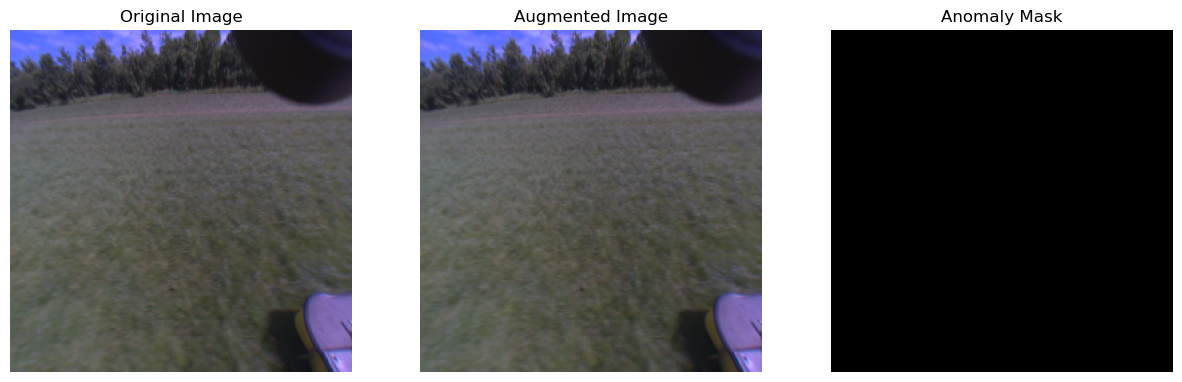

'\nbefore\n(256, 512, 3) (256, 512, 1) (1,)\nafter\n(3, 256, 512) (1, 256, 512) (1,)\n(256, 512, 3)\n'

In [304]:
import matplotlib.pyplot as plt

image_dir = '/home/maria/Documents/dataset_splited/agco_dataset/train/'
anomaly_source_dir = '/home/maria/Documents/datasets/dtd/images/'

dataset_perlin = CustomTrainDataset(image_dir=image_dir, anomaly_source_dir=anomaly_source_dir)

def visualize_sample(dataset, method):
    sample = dataset[random.randint(0, len(dataset) - 1)]

    image = sample['image'].transpose(1, 2, 0)
    print(type(image), image.max(), image.min())
    augmented_image = sample['augmented_image'].transpose(1, 2, 0)
    print(type(augmented_image), augmented_image.max(), augmented_image.min())
    anomaly_mask = sample['anomaly_mask'].transpose(1, 2, 0).squeeze()
    print(type(anomaly_mask), anomaly_mask.max(), anomaly_mask.min())

    print(augmented_image.shape)
    
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(augmented_image)
    plt.title("Augmented Image")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(anomaly_mask, cmap='gray')
    plt.title("Anomaly Mask")
    plt.axis('off')

    plt.show()

visualize_sample(dataset_perlin, method='Perlin')

"""
before
(256, 512, 3) (256, 512, 1) (1,)
after
(3, 256, 512) (1, 256, 512) (1,)
(256, 512, 3)
"""